API Thingies

In [ ]:
import requests

API = None
BASE_URL = 'https://ws.audioscrobbler.com/2.0/'

Function to get tags

In [2]:
def get_track_tags(artist: str, track: str, api_key: str, limit: int = 50) -> list[dict]:
    '''Get top tags for a song from last.fm.
    Returns a list of dictionaries with keys 'name' and 'count'.
    '''
    params = {
        'method': 'track.getTopTags',
        'artist': artist,
        'track': track,
        'api_key': api_key,
        'format': 'json'
    }

    response = requests.get(BASE_URL, params=params, timeout=15)
    response.raise_for_status() # raises error if the request failed

    data = response.json()

    # Handle API-level errors (Last.fm returns JSON error codes) :)
    if 'error' in data:
        raise ValueError(f'Last.fm API error {data['error']}: {data.get('message')}')
    
    # Extract tags
    raw_tags = data.get('toptags', {}).get('tag', [])
    if isinstance(raw_tags, dict): # sometimes a tag is returned as a dict
        raw_tags = [raw_tags]

    tags = [{'name': t.get('name'), 'count': int(t.get('count', 0))} for t in raw_tags]
    return tags[:limit]

Artist / Song pair

In [3]:
artist = 'Public Enemy'
track = "By the Time I Get to Arizona"

Fetch the tags :)

In [4]:
tags = get_track_tags(artist, track, API)
print(f'Tags for "{track}" by {artist}:')
for i, t in enumerate(tags, 1):
    print(f'{i}. {t['name']} (count={t['count']})')

Tags for "By the Time I Get to Arizona" by Public Enemy:


Embeddings from Twitter

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import pandas as pd

# File is actually CSV despite .xls extension
df = pd.read_csv("/content/drive/MyDrive/User-Songs-Music-Group.xls")

df

,Unnamed: 0,created_at,music_source,title,artist,disorder,sentiment_direction,sentiment_score,music_url,lyric,emotion_anger_score,emotion_disgust_score,emotion_fear_score,emotion_joy_score,emotion_neutral_score,emotion_sadness_score,emotion_surprise_score,anonymized_author_id,anonymized_tweet_id
0,0,2021-06-25 01:18:42-04:00,spotify,Burnin Bridges / Long Day (feat. IDK),Quadeca,depression,POSITIVE,0.9971,https://open.spotify.com/track/0B5mjEPetRaVGBs...,Highest To Lowest: Quadeca LyricsQuadeca's Son...,0.0294,0.0014,0.0132,0.2346,0.0993,0.0832,0.5390,0ef1ff6f271d5cb3541f6995,e611b266fd0d9de7dd2696d2
1,1,2021-09-25 12:05:15-04:00,spotify,She's A Lady,Tom Jones,control,POSITIVE,0.9988,https://open.spotify.com/track/5QfQ5iROTerk3MZ...,She’s a Lady Lyrics[Verse 1]\nWell she's all y...,0.0271,0.0203,0.0071,0.1162,0.1262,0.0335,0.6696,12b35a1f4485cf4aff1a634a,c04e17b275379c024e6179a4
2,2,2022-05-14 16:57:16-04:00,spotify,Lilies of the Valley,David Byrne,control,POSITIVE,0.9532,https://open.spotify.com/track/5mwlD1lkAGHrd2l...,Lilies of the Valley Lyrics[Verse 1]\nMomma sh...,0.0252,0.0054,0.0556,0.5990,0.0678,0.2116,0.0354,12b35a1f4485cf4aff1a634a,a6b49eeb6e211e7940be6593
3,3,2021-05-24 10:04:29-04:00,spotify,School's Out,Alice Cooper,control,NEGATIVE,0.9995,https://open.spotify.com/track/5Z8EDau8uNcP1E8...,"School’s Out Lyrics[Verse 1]\nWell, we got no ...",0.1258,0.1330,0.0149,0.0306,0.1615,0.5014,0.0330,12b35a1f4485cf4aff1a634a,bc836b7694e9c922f374ee74
4,4,2022-01-09 15:12:28-05:00,spotify,Call My Friends,Shawn Mendes,depression,POSITIVE,0.9978,https://open.spotify.com/track/6KVxMOxlSYpC5nr...,"Call My Friends Lyrics[Verse 1]\nRight now, I'...",0.0016,0.0006,0.0015,0.0075,0.0055,0.9777,0.0057,3e06169cafdc66d26a9b9ebb,7970bb8c13ff94ee62102db0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78408,78408,2020-09-08 05:01:37-04:00,spotify,Sincerity Is Scary,The 1975,control,NEGATIVE,0.9992,https://open.spotify.com/track/6HguG9HRb1Ke1bh...,Sincerity Is Scary Lyrics[Verse 1]\nIrony is o...,0.8493,0.0488,0.0085,0.0034,0.0163,0.0450,0.0288,0a565f604873557ab8531953,604cb74f6f2b528dc783ce19
78409,78409,2020-08-14 04:47:01-04:00,spotify,BBIBBI,IU,control,NEGATIVE,0.9905,https://open.spotify.com/track/4as4XEOR03oGm1S...,IU - BBIBBI (English Translation) Lyrics[Verse...,0.1678,0.0083,0.0646,0.0146,0.0556,0.0404,0.6488,0a565f604873557ab8531953,d4d3dea422795defe088c9a6
78410,78410,2022-05-08 12:54:01-04:00,apple,7 Things,Miley Cyrus,control,NEGATIVE,0.9848,https://music.apple.com/us/album/7-things/1440...,"7 Things Lyrics[Intro]\n(Sha, sha, sha)\n\n[Ve...",0.0914,0.0246,0.3393,0.0870,0.0451,0.3945,0.0181,9964394c7207f82479ff2a6c,2b9f89a573a5f9aadd4b1f59
78411,78411,2021-10-15 18:40:26-04:00,apple,Mexican Radio,SPM,control,NEGATIVE,0.9800,https://music.apple.com/us/album/mexican-radio...,Mexican Radio Lyrics[Intro](Spoken)\nOne-doubl...,0.1279,0.0051,0.0146,0.1729,0.2288,0.2386,0.2120,17df8fc9f5a8a3f490ad478a,bba2027e3152da9d03f70bfa


In [7]:
print((df['disorder'] == 'depression').value_counts())

disorder
False    70196
True      8217
Name: count, dtype: int64


In [8]:
depression_pairs = (
    df.loc[df['disorder'] == 'depression', ['artist', 'title']]
    .drop_duplicates()
    .head(50)
    .reset_index(drop=True)
)

depression_pairs

,artist,title
0,Quadeca,Burnin Bridges / Long Day (feat. IDK)
1,Shawn Mendes,Call My Friends
2,Di Young,Pixel Pig
3,BabyTron,Cheat Code 2
4,Jim Jacobs,Hopelessly Devoted to You
5,Nas,Speechless
6,Alina Baraz,Off the Grid (feat. Khalid)
7,iLoveMakonnen,Tuesday (feat. Drake)
8,The Beach Boys,Let's Go Away For A While - Mono / Remastered
9,Black Bear,Black Bear


Russell model of emotions

This model represents emotion in a 2D space where the y-axis represents arousal, and the x-axis represents valence. Valence can be positive or negative, and Arousal is between calm and positive.

The valence arousal can be represented as vectors in a 2D observational space

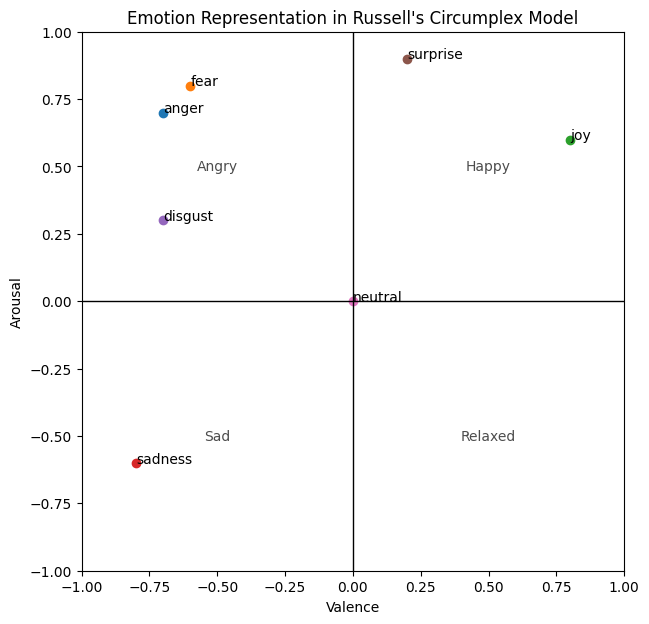

In [9]:
import matplotlib.pyplot as plt

emotions = {
    'anger': (-0.7, 0.7),
    'fear': (-0.6, 0.8),
    'joy': (0.8, 0.6),
    'sadness': (-0.8, -0.6),
    'disgust': (-0.7, 0.3),
    'surprise': (0.2, 0.9),
    'neutral': (0.0, 0.0),
}

fig, ax = plt.subplots(figsize=(7,7))

for emotion, (valence, arousal) in emotions.items():
    ax.scatter(valence, arousal)
    ax.text(valence, arousal, emotion)

ax.axhline(0, color='black', linewidth=1)
ax.axvline(0, color='black', linewidth=1)

ax.text(0.5, 0.5, "Happy", ha="center", va="center",
        fontsize=10, alpha=0.7)
ax.text(-0.5, 0.5, "Angry", ha="center", va="center",
        fontsize=10, alpha=0.7)
ax.text(-0.5, -0.5, "Sad", ha="center", va="center",
        fontsize=10, alpha=0.7)
ax.text(0.5, -0.5, "Relaxed", ha="center", va="center",
        fontsize=10, alpha=0.7)

ax.set_xlabel('Valence')
ax.set_ylabel('Arousal')
ax.set_title('Emotion Representation in Russell\'s Circumplex Model')

ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)

plt.show()

The folloing part labels the twitter songs in a 2D observational space using the theory presented in ANEW. This research ONLY shows you those words are perceived by a person

The valence/arousal values are derived directly from ANEW.

In [10]:
emotion_coordinates = {
    'emotion_anger_score': (2.50, 6.50),
    'emotion_fear_score': (3.60, 6.90),
    'emotion_sadness_score': (2.10, 3.40),
    'emotion_joy_score': (8.21, 6.10),
    'emotion_disgust_score': (2.50, 5.50),
    'emotion_surprise_score': (6.20, 6.00),
    'emotion_neutral_score': (5.00, 5.00), # neutral is often around the center of the circumplex, but these values can vary based on the dataset and method used to determine them
}

## Normalization Formula

To normalize values to the range $[-1, 1]$:

$$x_{normalized} = 2 \cdot \frac{x - x_{min}}{x_{max} - x_{min}} - 1$$

Or for the range $[0, 1]$:

$$x_{normalized} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

Where:
- $x$ is the original value
- $x_{min}$ is the minimum value in the dataset
- $x_{max}$ is the maximum value in the dataset

In [11]:
def normalize_coordinates(valence, arousal):
    '''Normalize valence and arousal to the range [-1, 1]'''
    norm_valence = (valence - 5) / 4
    norm_arousal = (arousal - 5) / 4
    return norm_valence, norm_arousal

Normalize the ANEW emotion coordinates

In [12]:
# Normalize all emotion coordinates
normalized_emotions = {emotion: normalize_coordinates(*coords) for emotion, coords in emotion_coordinates.items()}
normalized_emotions

{'emotion_anger_score': (-0.625, 0.375),
 'emotion_fear_score': (-0.35, 0.4750000000000001),
 'emotion_sadness_score': (-0.725, -0.4),
 'emotion_joy_score': (0.8025000000000002, 0.2749999999999999),
 'emotion_disgust_score': (-0.625, 0.125),
 'emotion_surprise_score': (0.30000000000000004, 0.25),
 'emotion_neutral_score': (0.0, 0.0)}

### Weighted Projection to Valence–Arousal Space

Each song has emotion scores \( w_e \) for different emotions \( e \).
Each emotion has a predefined position in the valence–arousal space:

- \( v_e \) : valence coordinate of emotion \( e \)
- \( a_e \) : arousal coordinate of emotion \( e \)

The emotional position of a song is computed using a weighted sum.

#### Valence

$$
V = \sum_{e} w_e \cdot v_e
$$

#### Arousal

$$
A = \sum_{e} w_e \cdot a_e
$$

Where:

- \( w_e \) is the emotion score of emotion \( e \) for the song  
- \( v_e \) is the valence coordinate of emotion \( e \)  
- \( a_e \) is the arousal coordinate of emotion \( e \)

The final emotional representation of a song is:

$$
(V, A)
$$

which corresponds to its position in the valence–arousal emotional space.

In [13]:
def song_to_va(song_row):

    valence, arousal = 0.0, 0.0

    for emotion, (v, a) in normalized_emotions.items():
        weight = song_row[emotion]

        valence += weight * v
        arousal += weight * a

    

    return valence, arousal

In [14]:
df[['valence', 'arousal']] = df.apply(lambda row: song_to_va(row),
                                        axis=1,
                                        result_type='expand')

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(-1, 1))
df[['valence', 'arousal']] = scaler.fit_transform(df[['valence', 'arousal']])

In [15]:
df

,Unnamed: 0,created_at,music_source,title,artist,disorder,sentiment_direction,sentiment_score,music_url,lyric,...,emotion_disgust_score,emotion_fear_score,emotion_joy_score,emotion_neutral_score,emotion_sadness_score,emotion_surprise_score,anonymized_author_id,anonymized_tweet_id,valence,arousal
0,0,2021-06-25 01:18:42-04:00,spotify,Burnin Bridges / Long Day (feat. IDK),Quadeca,depression,POSITIVE,0.9971,https://open.spotify.com/track/0B5mjEPetRaVGBs...,Highest To Lowest: Quadeca LyricsQuadeca's Son...,...,0.0014,0.0132,0.2346,0.0993,0.0832,0.5390,0ef1ff6f271d5cb3541f6995,e611b266fd0d9de7dd2696d2,0.300440,0.333046
1,1,2021-09-25 12:05:15-04:00,spotify,She's A Lady,Tom Jones,control,POSITIVE,0.9988,https://open.spotify.com/track/5QfQ5iROTerk3MZ...,She’s a Lady Lyrics[Verse 1]\nWell she's all y...,...,0.0203,0.0071,0.1162,0.1262,0.0335,0.6696,12b35a1f4485cf4aff1a634a,c04e17b275379c024e6179a4,0.263476,0.375775
2,2,2022-05-14 16:57:16-04:00,spotify,Lilies of the Valley,David Byrne,control,POSITIVE,0.9532,https://open.spotify.com/track/5mwlD1lkAGHrd2l...,Lilies of the Valley Lyrics[Verse 1]\nMomma sh...,...,0.0054,0.0556,0.5990,0.0678,0.2116,0.0354,12b35a1f4485cf4aff1a634a,a6b49eeb6e211e7940be6593,0.344658,0.199640
3,3,2021-05-24 10:04:29-04:00,spotify,School's Out,Alice Cooper,control,NEGATIVE,0.9995,https://open.spotify.com/track/5Z8EDau8uNcP1E8...,"School’s Out Lyrics[Verse 1]\nWell, we got no ...",...,0.1330,0.0149,0.0306,0.1615,0.5014,0.0330,12b35a1f4485cf4aff1a634a,bc836b7694e9c922f374ee74,-0.703709,-0.349047
4,4,2022-01-09 15:12:28-05:00,spotify,Call My Friends,Shawn Mendes,depression,POSITIVE,0.9978,https://open.spotify.com/track/6KVxMOxlSYpC5nr...,"Call My Friends Lyrics[Verse 1]\nRight now, I'...",...,0.0006,0.0015,0.0075,0.0055,0.9777,0.0057,3e06169cafdc66d26a9b9ebb,7970bb8c13ff94ee62102db0,-0.976535,-0.977568
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78408,78408,2020-09-08 05:01:37-04:00,spotify,Sincerity Is Scary,The 1975,control,NEGATIVE,0.9992,https://open.spotify.com/track/6HguG9HRb1Ke1bh...,Sincerity Is Scary Lyrics[Verse 1]\nIrony is o...,...,0.0488,0.0085,0.0034,0.0163,0.0450,0.0288,0a565f604873557ab8531953,604cb74f6f2b528dc783ce19,-0.821708,0.644341
78409,78409,2020-08-14 04:47:01-04:00,spotify,BBIBBI,IU,control,NEGATIVE,0.9905,https://open.spotify.com/track/4as4XEOR03oGm1S...,IU - BBIBBI (English Translation) Lyrics[Verse...,...,0.0083,0.0646,0.0146,0.0556,0.0404,0.6488,0a565f604873557ab8531953,d4d3dea422795defe088c9a6,0.008630,0.473958
78410,78410,2022-05-08 12:54:01-04:00,apple,7 Things,Miley Cyrus,control,NEGATIVE,0.9848,https://music.apple.com/us/album/7-things/1440...,"7 Things Lyrics[Intro]\n(Sha, sha, sha)\n\n[Ve...",...,0.0246,0.3393,0.0870,0.0451,0.3945,0.0181,9964394c7207f82479ff2a6c,2b9f89a573a5f9aadd4b1f59,-0.579800,0.070105
78411,78411,2021-10-15 18:40:26-04:00,apple,Mexican Radio,SPM,control,NEGATIVE,0.9800,https://music.apple.com/us/album/mexican-radio...,Mexican Radio Lyrics[Intro](Spoken)\nOne-doubl...,...,0.0051,0.0146,0.1729,0.2288,0.2386,0.2120,17df8fc9f5a8a3f490ad478a,bba2027e3152da9d03f70bfa,-0.127482,0.050492


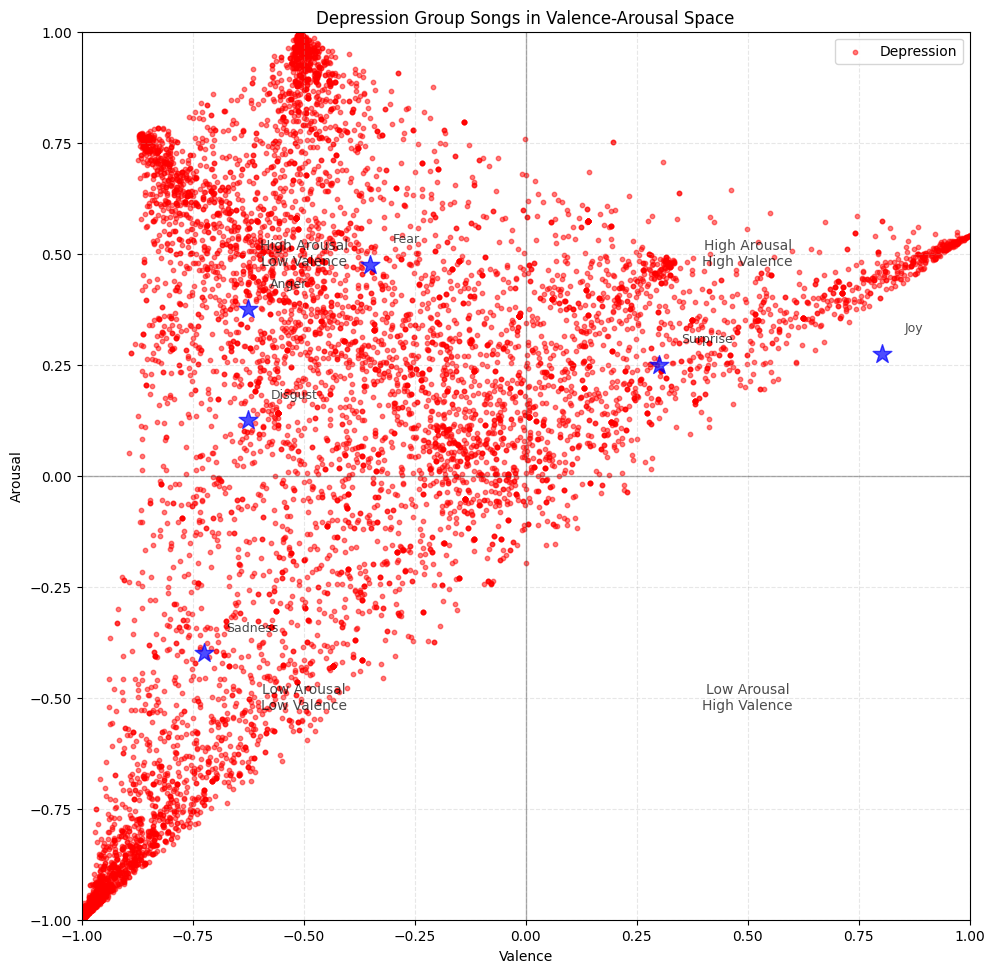

Total songs in depression group: 8217
Average valence: -0.381
Average arousal: 0.153


In [16]:
depression_df = df[df['disorder'] == 'depression']

fig, ax = plt.subplots(figsize=(10,10))

ax.scatter(depression_df['valence'], depression_df['arousal'], alpha=0.5, s=10, c='red', label='Depression')

emotion_ref = {
    'Anger': (-0.625, 0.375),
    'Fear': (-0.35, 0.475),
    'Joy': (0.8025, 0.275),
    'Sadness': (-0.725, -0.4),
    'Disgust': (-0.625, 0.125),
    'Surprise': (0.3, 0.25),
}

for emotion, (v, a) in emotion_ref.items():
    ax.scatter(v, a, marker='*', s=200, c='blue', alpha=0.7)
    ax.text(v + 0.05, a + 0.05, emotion, fontsize=9, alpha=0.7)

ax.axhline(0, color='black', linewidth=1, alpha=0.3)
ax.axvline(0, color='black', linewidth=1, alpha=0.3)

ax.text(0.5, 0.5, 'High Arousal\nHigh Valence', ha='center', va='center', fontsize=10, alpha=0.7)
ax.text(-0.5, 0.5, 'High Arousal\nLow Valence', ha='center', va='center', fontsize=10, alpha=0.7)
ax.text(-0.5, -0.5, 'Low Arousal\nLow Valence', ha='center', va='center', fontsize=10, alpha=0.7)
ax.text(0.5, -0.5, 'Low Arousal\nHigh Valence', ha='center', va='center', fontsize=10, alpha=0.7)

ax.set_xlabel('Valence')
ax.set_ylabel('Arousal')
ax.set_title('Depression Group Songs in Valence-Arousal Space')
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_aspect('equal', adjustable='box')
ax.grid(True, linestyle='--', alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

print(f'Total songs in depression group: {len(depression_df)}')
print(f'Average valence: {depression_df["valence"].mean():.3f}')
print(f'Average arousal: {depression_df["arousal"].mean():.3f}')

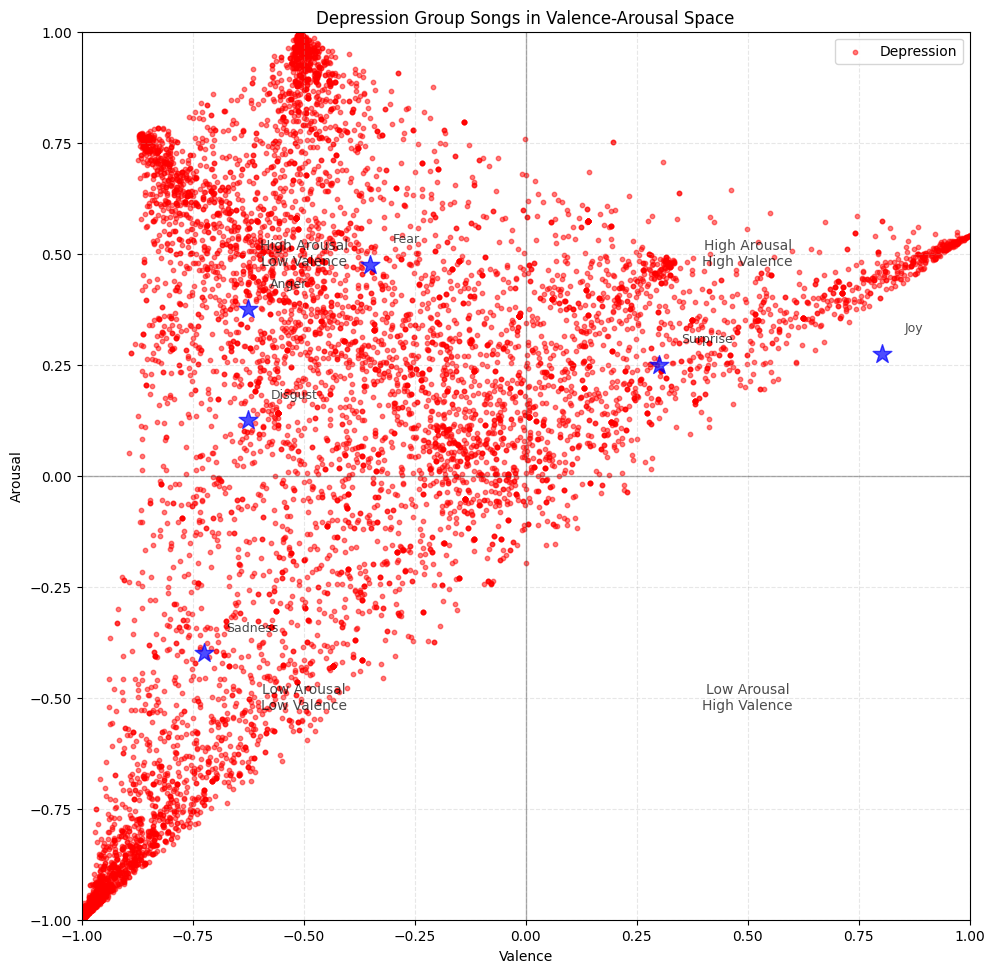

Total songs in depression group: 8217
Average valence: -0.381
Average arousal: 0.153


In [17]:
depression_df = df[df['disorder'] == 'depression']

fig, ax = plt.subplots(figsize=(10,10))

ax.scatter(depression_df['valence'], depression_df['arousal'], alpha=0.5, s=10, c='red', label='Depression')

emotion_ref = {
    'Anger': (-0.625, 0.375),
    'Fear': (-0.35, 0.475),
    'Joy': (0.8025, 0.275),
    'Sadness': (-0.725, -0.4),
    'Disgust': (-0.625, 0.125),
    'Surprise': (0.3, 0.25),
}

for emotion, (v, a) in emotion_ref.items():
    ax.scatter(v, a, marker='*', s=200, c='blue', alpha=0.7)
    ax.text(v + 0.05, a + 0.05, emotion, fontsize=9, alpha=0.7)

ax.axhline(0, color='black', linewidth=1, alpha=0.3)
ax.axvline(0, color='black', linewidth=1, alpha=0.3)

ax.text(0.5, 0.5, 'High Arousal\nHigh Valence', ha='center', va='center', fontsize=10, alpha=0.7)
ax.text(-0.5, 0.5, 'High Arousal\nLow Valence', ha='center', va='center', fontsize=10, alpha=0.7)
ax.text(-0.5, -0.5, 'Low Arousal\nLow Valence', ha='center', va='center', fontsize=10, alpha=0.7)
ax.text(0.5, -0.5, 'Low Arousal\nHigh Valence', ha='center', va='center', fontsize=10, alpha=0.7)

ax.set_xlabel('Valence')
ax.set_ylabel('Arousal')
ax.set_title('Depression Group Songs in Valence-Arousal Space')
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_aspect('equal', adjustable='box')
ax.grid(True, linestyle='--', alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

print(f'Total songs in depression group: {len(depression_df)}')
print(f'Average valence: {depression_df["valence"].mean():.3f}')
print(f'Average arousal: {depression_df["arousal"].mean():.3f}')

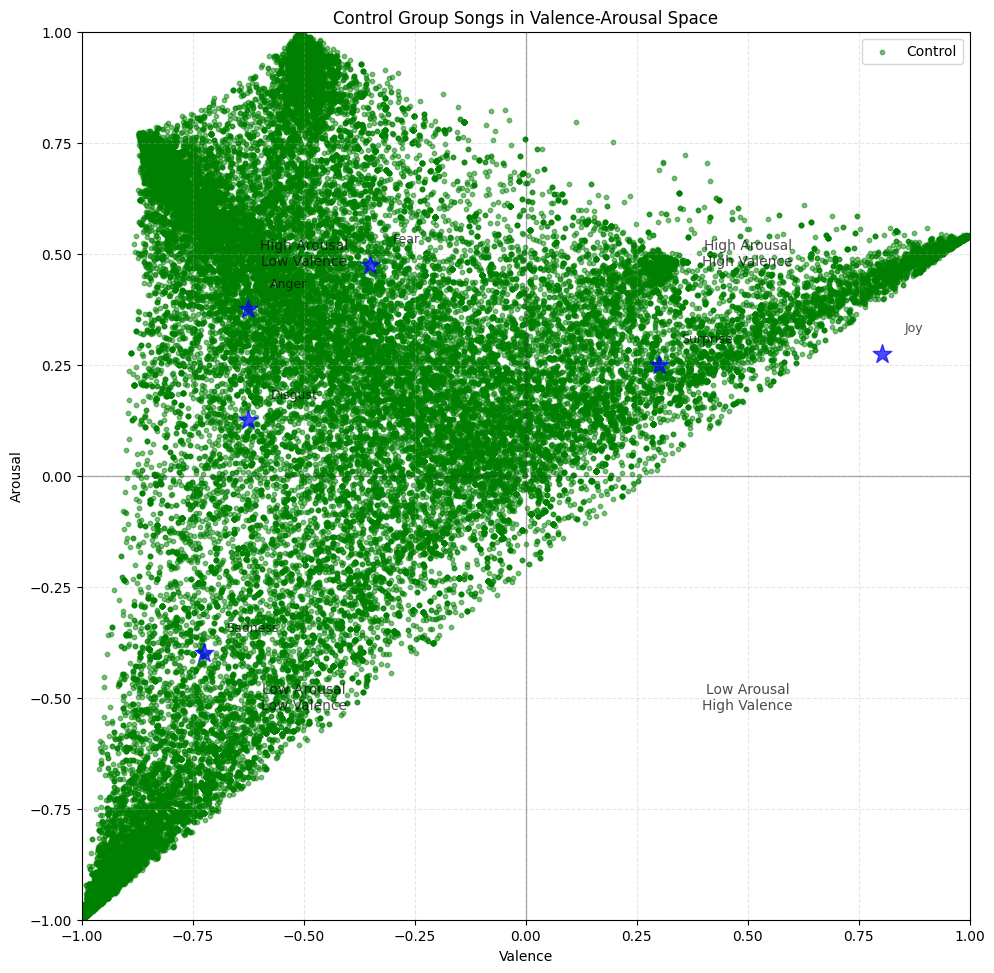

Total songs in control group: 56840
Average valence: -0.388
Average arousal: 0.181


In [18]:
control_df = df[df['disorder'] == 'control']

fig, ax = plt.subplots(figsize=(10,10))

ax.scatter(control_df['valence'], control_df['arousal'], alpha=0.5, s=10, c='green', label='Control')

emotion_ref = {
    'Anger': (-0.625, 0.375),
    'Fear': (-0.35, 0.475),
    'Joy': (0.8025, 0.275),
    'Sadness': (-0.725, -0.4),
    'Disgust': (-0.625, 0.125),
    'Surprise': (0.3, 0.25),
}

for emotion, (v, a) in emotion_ref.items():
    ax.scatter(v, a, marker='*', s=200, c='blue', alpha=0.7)
    ax.text(v + 0.05, a + 0.05, emotion, fontsize=9, alpha=0.7)

ax.axhline(0, color='black', linewidth=1, alpha=0.3)
ax.axvline(0, color='black', linewidth=1, alpha=0.3)

ax.text(0.5, 0.5, 'High Arousal\nHigh Valence', ha='center', va='center', fontsize=10, alpha=0.7)
ax.text(-0.5, 0.5, 'High Arousal\nLow Valence', ha='center', va='center', fontsize=10, alpha=0.7)
ax.text(-0.5, -0.5, 'Low Arousal\nLow Valence', ha='center', va='center', fontsize=10, alpha=0.7)
ax.text(0.5, -0.5, 'Low Arousal\nHigh Valence', ha='center', va='center', fontsize=10, alpha=0.7)

ax.set_xlabel('Valence')
ax.set_ylabel('Arousal')
ax.set_title('Control Group Songs in Valence-Arousal Space')
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_aspect('equal', adjustable='box')
ax.grid(True, linestyle='--', alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

print(f'Total songs in control group: {len(control_df)}')
print(f'Average valence: {control_df["valence"].mean():.3f}')
print(f'Average arousal: {control_df["arousal"].mean():.3f}')

In [19]:
print(depression_df['lyric'][4])

Call My Friends Lyrics[Verse 1]
Right now, I'm alone inside the airport
And you're all at a bar in our hometown
Feels like we've been living different lives
The music's loud and everybody's dancing
How many nights I've missed, yeah, I've lost count
Haven't seen your faces in a while

[Chorus]
I should call my friends
I should call my friends and go get high
I need a vacation from my mind
I wanna go, nobody knows me better than them
Wanna feel something again
I should call my friends
[Verse 2]
I don't wanna miss another birthday
Feels like it's been forever since nineteen
I just wanna be right where you are
I miss how it was when we wishеd we were oldеr
Feeling so far when I wanna be closer

[Chorus]
I should call my friends
I should call my friends and go get high
I need a vacation from my mind
I wanna go, nobody knows me better than them
Wanna feel something again
I should call my friends

[Bridge]
Ooh, I know you gotta make some sacrifices
Ooh, don't wanna be alone for one more night

Lyrics analysis

In [20]:
from transformers import pipeline

In [21]:
model_name = 'bhadresh-savani/bert-base-uncased-emotion'

emotion_classifier = pipeline(
    task='text-classification',
    model=model_name,
    tokenizer=model_name,
    truncation=True,
)

print('Model loadeed successfully!')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bhadresh-savani/bert-base-uncased-emotion
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loadeed successfully!


In [22]:
sample = "Boom, boom, boom, boom, I want you in my room, let's spend the night together, from now until forever, boom, boom, boom, boom, I want you in my room, let's spend the night together, together in my room"
emotion_classifier(sample)

[{'label': 'joy', 'score': 0.5224265456199646}]

Clean the lyrics column

In [23]:
import re

LYRICS_COL = 'lyric'

def clean_lyrics(text: str) -> str:
    if pd.isna(text):
        return ''
    text = str(text)

    # remove tags
    text = re.sub(r"\[.*?\]|\(.*?\)", " ", text) 

    # remove URLs
    text = re.sub(r"http\S+|www\.\S+", " ", text)

    # normalize apostrophes an quotes
    text = text.replace("’", "'").replace("“", '"').replace("”", '"')

    # keep letter, numbers, and basic punctuation
    text = re.sub(r"[^a-zA-Z0-9\s.,!?;:'\"-]", " ", text)

    # collapse repeated spaces/newlines
    text = re.sub(r"\s+", " ", text).strip()

    return text

# cleaned lyrics column
df['lyrics_clean'] = df[LYRICS_COL].apply(clean_lyrics)

df[[LYRICS_COL, 'lyrics_clean']].head(5)


,lyric,lyrics_clean
0,Highest To Lowest: Quadeca LyricsQuadeca's Son...,Highest To Lowest: Quadeca LyricsQuadeca's Son...
1,She’s a Lady Lyrics[Verse 1]\nWell she's all y...,She's a Lady Lyrics Well she's all you'd ever ...
2,Lilies of the Valley Lyrics[Verse 1]\nMomma sh...,Lilies of the Valley Lyrics Momma she had comp...
3,"School’s Out Lyrics[Verse 1]\nWell, we got no ...","School's Out Lyrics Well, we got no choice All..."
4,"Call My Friends Lyrics[Verse 1]\nRight now, I'...","Call My Friends Lyrics Right now, I'm alone in..."


In [24]:
# Batch processing for efficiency
print('Starting emotion classification in batches...')

# Prepare texts for batch processing
texts = df['lyrics_clean'].fillna('').astype(str).tolist()

# Truncate texts to 5000 characters (BERT token limit considerations)
texts_truncated = [text[:5000] if text else '' for text in texts]

# Filter out empty texts and track their indices
valid_indices = [i for i, text in enumerate(texts_truncated) if text.strip()]
valid_texts = [texts_truncated[i] for i in valid_indices]

print(f'Processing {len(valid_texts)} non-empty lyrics in batches...')

# Process in batches (much more efficient!)
# batch_size=16 is good for most GPUs, adjust based on your memory
results = emotion_classifier(valid_texts, batch_size=16, truncation=True, max_length=512)

# Initialize with default values
all_emotions = ['neutral'] * len(df)
all_confidences = [0.0] * len(df)

# Fill in results for valid indices
for i, result in zip(valid_indices, results):
    all_emotions[i] = result['label']
    all_confidences[i] = result['score']

# Assign to dataframe
df['bert_emotion'] = all_emotions
df['bert_confidence'] = all_confidences

print(f'Emotion classification completed!')
print(f'\nSample results:')
print(df[['artist', 'title', 'bert_emotion', 'bert_confidence']].head(10))

Starting emotion classification in batches...
Processing 78413 non-empty lyrics in batches...
Emotion classification completed!

Sample results:
             artist                                        title bert_emotion  \
0           Quadeca        Burnin Bridges / Long Day (feat. IDK)          joy   
1         Tom Jones                                 She's A Lady          joy   
2       David Byrne                         Lilies of the Valley      sadness   
3      Alice Cooper                                 School's Out      sadness   
4      Shawn Mendes                              Call My Friends      sadness   
5        X-Ray Spex                        Oh Bondage! Up Yours!        anger   
6     Nat King Cole  The Christmas Song (Merry Christmas To You)          joy   
7  Richard C. Rocha                             Winds of Freedom        anger   
8  Richard C. Rocha                             Winds of Freedom        anger   
9       Ann Peebles                       I C

In [26]:
df.to_csv("/content/drive/MyDrive/lyrics_emotions.csv", index=False)

In [28]:
df_emotions = pd.read_csv("/content/drive/MyDrive/lyrics_emotions.csv")

df_emotions.head()

,Unnamed: 0,created_at,music_source,title,artist,disorder,sentiment_direction,sentiment_score,music_url,lyric,...,emotion_neutral_score,emotion_sadness_score,emotion_surprise_score,anonymized_author_id,anonymized_tweet_id,valence,arousal,lyrics_clean,bert_emotion,bert_confidence
0,0,2021-06-25 01:18:42-04:00,spotify,Burnin Bridges / Long Day (feat. IDK),Quadeca,depression,POSITIVE,0.9971,https://open.spotify.com/track/0B5mjEPetRaVGBs...,Highest To Lowest: Quadeca LyricsQuadeca's Son...,...,0.0993,0.0832,0.5390,0ef1ff6f271d5cb3541f6995,e611b266fd0d9de7dd2696d2,0.300440,0.333046,Highest To Lowest: Quadeca LyricsQuadeca's Son...,joy,0.983130
1,1,2021-09-25 12:05:15-04:00,spotify,She's A Lady,Tom Jones,control,POSITIVE,0.9988,https://open.spotify.com/track/5QfQ5iROTerk3MZ...,She’s a Lady Lyrics[Verse 1]\nWell she's all y...,...,0.1262,0.0335,0.6696,12b35a1f4485cf4aff1a634a,c04e17b275379c024e6179a4,0.263476,0.375775,She's a Lady Lyrics Well she's all you'd ever ...,joy,0.503159
2,2,2022-05-14 16:57:16-04:00,spotify,Lilies of the Valley,David Byrne,control,POSITIVE,0.9532,https://open.spotify.com/track/5mwlD1lkAGHrd2l...,Lilies of the Valley Lyrics[Verse 1]\nMomma sh...,...,0.0678,0.2116,0.0354,12b35a1f4485cf4aff1a634a,a6b49eeb6e211e7940be6593,0.344658,0.199640,Lilies of the Valley Lyrics Momma she had comp...,sadness,0.994102
3,3,2021-05-24 10:04:29-04:00,spotify,School's Out,Alice Cooper,control,NEGATIVE,0.9995,https://open.spotify.com/track/5Z8EDau8uNcP1E8...,"School’s Out Lyrics[Verse 1]\nWell, we got no ...",...,0.1615,0.5014,0.0330,12b35a1f4485cf4aff1a634a,bc836b7694e9c922f374ee74,-0.703709,-0.349047,"School's Out Lyrics Well, we got no choice All...",sadness,0.925512
4,4,2022-01-09 15:12:28-05:00,spotify,Call My Friends,Shawn Mendes,depression,POSITIVE,0.9978,https://open.spotify.com/track/6KVxMOxlSYpC5nr...,"Call My Friends Lyrics[Verse 1]\nRight now, I'...",...,0.0055,0.9777,0.0057,3e06169cafdc66d26a9b9ebb,7970bb8c13ff94ee62102db0,-0.976535,-0.977568,"Call My Friends Lyrics Right now, I'm alone in...",sadness,0.859243


In [29]:
# final dataset with emotions from BERT and valence/arousal coordinates for analysis and visualization
df_final = df_emotions[[
    'artist', 'title', 'disorder', 'bert_emotion', 'bert_confidence', 'valence', 'arousal', 'lyrics_clean'
]].copy()

df_final.head()

,artist,title,disorder,bert_emotion,bert_confidence,valence,arousal,lyrics_clean
0,Quadeca,Burnin Bridges / Long Day (feat. IDK),depression,joy,0.983130,0.300440,0.333046,Highest To Lowest: Quadeca LyricsQuadeca's Son...
1,Tom Jones,She's A Lady,control,joy,0.503159,0.263476,0.375775,She's a Lady Lyrics Well she's all you'd ever ...
2,David Byrne,Lilies of the Valley,control,sadness,0.994102,0.344658,0.199640,Lilies of the Valley Lyrics Momma she had comp...
3,Alice Cooper,School's Out,control,sadness,0.925512,-0.703709,-0.349047,"School's Out Lyrics Well, we got no choice All..."
4,Shawn Mendes,Call My Friends,depression,sadness,0.859243,-0.976535,-0.977568,"Call My Friends Lyrics Right now, I'm alone in..."


In [30]:
df_final.to_csv("/content/drive/MyDrive/lyrics_emotions.csv", index=False)